# Variational Autoencoders: ELBO, Inference, and Learning

Generative modeling can be formulated as a **maximum likelihood** problem. We observe samples $\boldsymbol{x}_1,\ldots,\boldsymbol{x}_n$ from an unknown data distribution $p_{gt}(\boldsymbol{x})$, and we introduce a parametric model $p_\theta(\boldsymbol{x})$ that should assign high probability to images that could plausibly come from that distribution. In population form, the ideal objective is

:::{math}
\theta^\star
\in
\arg\max_\theta
\mathbb{E}_{\boldsymbol{x}\sim p_{gt}}
\left[
\log p_\theta(\boldsymbol{x})
\right],
:::

and in finite data form this becomes the **empirical log-likelihood**

:::{math}
\theta^\star
\in
\arg\max_\theta
\frac{1}{n}
\sum_{i=1}^{n}
\log p_\theta(\boldsymbol{x}_i).
:::

The **deep latent-variable view** developed earlier gives a structured way to define $p_\theta(\boldsymbol{x})$. An image is assumed to be generated from hidden factors $\boldsymbol{z}$, such as shape, pose, thickness, or style. The joint model is $p_\theta(\boldsymbol{x},\boldsymbol{z}) = p_\theta(\boldsymbol{x}|\boldsymbol{z})p(\boldsymbol{z})$, so generation has two steps: sample $\boldsymbol{z}$ from a prior, then sample or decode $\boldsymbol{x}$ from $p_\theta(\boldsymbol{x}|\boldsymbol{z})$. The marginal likelihood required by maximum likelihood is therefore 

:::{math}
p_\theta(\boldsymbol{x}) = \int p_\theta(\boldsymbol{x}|\boldsymbol{z})p(\boldsymbol{z}) \,d\boldsymbol{z}.
:::

The usual prior choice is $p(\boldsymbol{z}) = \mathcal{N}(\boldsymbol{0},\boldsymbol{I})$.

This **Gaussian prior** is a *modeling assumption*. It gives a simple latent reference distribution that is easy to sample, has a smooth geometry, and leads to analytic **KL term**s. The assumption is useful because the decoder is nonlinear: a neural network can transform a simple latent distribution into a complicated image distribution. The cost of this simplicity is that the model must learn a latent organization compatible with the standard **Gaussian prior**.

```{figure} ../assets/images/VAE_probability.png
:width: 66%
:align: center

Not all the samples $\boldsymbol{z} \sim p(\boldsymbol{z})$ are equally relevant for $p_\theta(\boldsymbol{x} | \boldsymbol{z})$.
```

The difficulty appears immediately. The integral defining $p_\theta(\boldsymbol{x})$ is usually intractable. The latent variable may be high-dimensional, and the decoder is a neural network, so the integral has no closed form. Direct maximum likelihood is therefore blocked.

A natural idea is to focus on the latent values that matter for the observed image. If $\boldsymbol{x}$ is a boot, not every $\boldsymbol{z}$ is equally relevant. Some latent configurations should explain that image much better than others. This suggests looking at the **posterior distribution** over latent variables:

:::{math}
p_\theta(\boldsymbol{z}|\boldsymbol{x})
=
\frac{
p_\theta(\boldsymbol{x}|\boldsymbol{z})p(\boldsymbol{z})
}{
p_\theta(\boldsymbol{x})
}
=
\frac{
p_\theta(\boldsymbol{x}|\boldsymbol{z})p(\boldsymbol{z})
}{
\int p_\theta(\boldsymbol{x}|\boldsymbol{z})p(\boldsymbol{z})\,d\boldsymbol{z}
}.
:::

This posterior is exactly the distribution one would like to use for inference. It tells us which latent explanations are plausible after seeing the image. Unfortunately, Bayes' theorem has not removed the problem. The denominator is the same **intractable marginal likelihood**. The posterior is therefore intractable for the same reason the likelihood is intractable.

The **variational idea** is to introduce a new distribution $q_\phi(\boldsymbol{z}|\boldsymbol{x})$, chosen from a tractable family and implemented by a neural network. Its role is to approximate the **true posterior** $p_\theta(\boldsymbol{z}|\boldsymbol{x})$. This is the **recognition model**, or encoder. The word *variational* means that exact inference is replaced by optimization over an approximate family. The VAE is built from this compromise: the decoder defines the generative model, while the encoder makes approximate posterior inference fast enough to train the model.

```{figure} ../assets/images/VAE_gen.png
:width: 80%
:align: center

The autoencoder-like structure of VAE.
```

## Derivation of the Evidence Lower Bound

Start from the log-likelihood of one observation. For any tractable density $q_\phi(\boldsymbol{z}|\boldsymbol{x})$ whose support covers the relevant latent region, write

:::{math}
\log p_\theta(\boldsymbol{x})
=
\log
\int
q_\phi(\boldsymbol{z}|\boldsymbol{x})
\frac{
p_\theta(\boldsymbol{x},\boldsymbol{z})
}{
q_\phi(\boldsymbol{z}|\boldsymbol{x})
}
\,d\boldsymbol{z}.
:::

This identity only multiplies and divides by the approximate posterior. It does not approximate anything yet. The approximation enters when Jensen's inequality is applied to move the logarithm inside the expectation.

```{prf:theorem} **Evidence lower bound**
:label: thm-elbo

For any density $q_\phi(\boldsymbol{z}|\boldsymbol{x})$ whose support contains the relevant support of $p_\theta(\boldsymbol{x},\boldsymbol{z})$,
:::{math}
\log p_\theta(\boldsymbol{x})
\geq
\mathbb{E}_{q_\phi(\boldsymbol{z}|\boldsymbol{x})}
\left[
\log p_\theta(\boldsymbol{x},\boldsymbol{z})
-
\log q_\phi(\boldsymbol{z}|\boldsymbol{x})
\right].
:::
The right-hand side is called the **evidence lower bound**, or ELBO.
```

```{prf:proof}
Write the marginal likelihood as an expectation under $q_\phi(\boldsymbol{z}|\boldsymbol{x})$:
:::{math}
\log p_\theta(\boldsymbol{x})
=
\log
\mathbb{E}_{q_\phi(\boldsymbol{z}|\boldsymbol{x})}
\left[
\frac{
p_\theta(\boldsymbol{x},\boldsymbol{z})
}{
q_\phi(\boldsymbol{z}|\boldsymbol{x})
}
\right].
:::
Since $\log$ is concave, Jensen's inequality gives
:::{math}
\log p_\theta(\boldsymbol{x})
\geq
\mathbb{E}_{q_\phi(\boldsymbol{z}|\boldsymbol{x})}
\left[
\log
\frac{
p_\theta(\boldsymbol{x},\boldsymbol{z})
}{
q_\phi(\boldsymbol{z}|\boldsymbol{x})
}
\right].
:::
Expanding the logarithm gives the stated expression.
```

The gap introduced by Jensen's inequality is the price paid for replacing exact marginalization with tractable posterior sampling. If $q_\phi(\boldsymbol{z}|\boldsymbol{x})$ matches the **true posterior**, the bound becomes tight. If it is a poor approximation, the bound may be loose even when the decoder is expressive.

```{figure} ../assets/images/ELBO_gap.png
:width: 66%
:align: center

Minimizing ELBO implicity optimizes the negative log-likelihood.
```

The ELBO becomes more interpretable after expanding the joint density:

:::{math}
\mathcal{L}_{ELBO}(\theta,\phi;\boldsymbol{x})
=
\mathbb{E}_{q_\phi(\boldsymbol{z}|\boldsymbol{x})}
\left[
\log p_\theta(\boldsymbol{x}|\boldsymbol{z})
\right]
-
\operatorname{KL}
\left(
q_\phi(\boldsymbol{z}|\boldsymbol{x}) \| p(\boldsymbol{z})
\right).
:::

This is the key moment where the VAE begins to look like an autoencoder. The first term asks the decoder to reconstruct or explain $\boldsymbol{x}$ from latent samples produced by the encoder. If the observation model is Bernoulli, this term becomes a binary cross-entropy reconstruction criterion. If the observation model is Gaussian with fixed variance, it becomes proportional to a squared-error reconstruction criterion:

```{prf:theorem} VAE as regularized autoencoder
:label: vae-autoencoder

Assuming $p_\theta(\boldsymbol{x} | \boldsymbol{z}) = \mathcal{N}(\mu_\theta(\boldsymbol{z}), \sigma^2 \boldsymbol{I})$, where $\mu_\theta(\boldsymbol{z})$ is a neural network, then:
:::{math}
\mathbb{E}_{q_\phi(\boldsymbol{z}|\boldsymbol{x})}
\left[
\log p_\theta(\boldsymbol{x}|\boldsymbol{z})
\right]
:::
is a Mean Squared Error (MSE) term between the output $\mu_\theta(\boldsymbol{z})$ of the neural network, and the true image $\boldsymbol{x}$.
```

```{prf:proof}
Recall that $\mathcal{N}(\mu_\theta(\boldsymbol{z}), \sigma^2 \boldsymbol{I})$ corresponds to:

:::{math}
\mathcal{N}(\mu_\theta(\boldsymbol{z}), \sigma^2 \boldsymbol{I}) = \frac{1}{\left( 2 \pi \sigma^2 \right)^{\frac{d}{2}}} \exp \left( - \frac{ \left\| \boldsymbol{x} - \mu_\theta(\boldsymbol{z}) \right\|^2}{2\sigma^2} \right).
:::

Therefore:

:::{math}
\log p_\theta(\boldsymbol{z} | \boldsymbol{x}) = - \frac{d}{2} \log \left( 2 \pi \sigma^2 \right) - \frac{ \left\| \boldsymbol{x} - \mu_\theta(\boldsymbol{z}) \right\|^2}{2\sigma^2}.
:::

Removing the terms that does not depend on $\theta$ (whose gradient is zero), it we obtain $\log p_\theta(\boldsymbol{z} | \boldsymbol{x}) \propto - \frac{ \left\| \boldsymbol{x} - \mu_\theta(\boldsymbol{z}) \right\|^2}{2\sigma^2}$, which is precisely the MSE between $\boldsymbol{x}$ and $\mu_\theta(\boldsymbol{z})$.
```

The second term is the **regularizer**. It compares the encoder distribution for this image with the prior distribution used for generation. Without this term, the encoder could place each training image in arbitrary isolated regions of **latent space**, producing a deterministic autoencoder that reconstructs well but cannot be sampled reliably. With the **KL term**, the encoded distributions are encouraged to live near a common reference geometry. This is why sampling from $p(\boldsymbol{z})$ after training has a chance to produce meaningful images.

In loss-minimization form, one minimizes the **negative ELBO**:

:::{math}
-\mathcal{L}_{ELBO}
=
\underbrace{
\mathbb{E}_{q_\phi(\boldsymbol{z}|\boldsymbol{x})}
\left[
-\log p_\theta(\boldsymbol{x}|\boldsymbol{z})
\right]
}_{\text{reconstruction loss}}
+
\underbrace{
\operatorname{KL}
\left(
q_\phi(\boldsymbol{z}|\boldsymbol{x}) \| p(\boldsymbol{z})
\right)
}_{\text{latent regularization}}.
:::

This is the reconstruction-plus-regularization form used in implementation.

```{admonition} Reading the ELBO
:class: note

The ELBO has two simultaneous roles. It is a tractable lower bound on the intractable log-likelihood, and it is the objective that gives the VAE its autoencoder-like form: a **reconstruction term** plus a KL regularization term.
```

```{prf:theorem} ELBO decomposition with posterior gap
:label: thm-elbo-gap

For every observation $\boldsymbol{x}$,
:::{math}
\log p_\theta(\boldsymbol{x})
=
\mathcal{L}_{ELBO}(\theta, \phi; \boldsymbol{x})
+
\operatorname{KL}\big(q_\phi(\boldsymbol{z} | \boldsymbol{x}) \| p_\theta(\boldsymbol{z} | \boldsymbol{x})\big).
:::
```

```{prf:proof}
Starting from the ELBO expression,
:::{math}
\mathcal{L}_{ELBO}
=
\mathbb{E}_{q_\phi}
[\log p_\theta(\boldsymbol{x}, \boldsymbol{z}) - \log q_\phi(\boldsymbol{z} | \boldsymbol{x})].
:::
Add and subtract $\log p_\theta(\boldsymbol{z} | \boldsymbol{x})$. Using
:::{math}
\log p_\theta(\boldsymbol{x}, \boldsymbol{z})
=
\log p_\theta(\boldsymbol{z} | \boldsymbol{x}) + \log p_\theta(\boldsymbol{x}),
:::
we obtain
:::{math}
\mathcal{L}_{ELBO}
=
\log p_\theta(\boldsymbol{x})
-
\mathbb{E}_{q_\phi}
\left[
\log \frac{q_\phi(\boldsymbol{z} | \boldsymbol{x})}{p_\theta(\boldsymbol{z} | \boldsymbol{x})}
\right].
:::
The expectation is exactly the Kullback-Leibler divergence between the approximate and exact posterior, which proves the identity.
```

The identity explains why the bound is useful. Maximizing the ELBO pushes upward the data log-likelihood while pushing downward the gap between the **recognition model** and the **true posterior**. The quality of generation and the quality of inference are therefore coupled. If the approximate posterior family is too restrictive, the learned decoder may adapt to what the encoder can represent rather than to the best possible latent-variable explanation of the data.

The same identity also explains why the ELBO can be viewed as a controlled approximation to maximum likelihood. The real target is still $\log p_\theta(\boldsymbol{x})$. The ELBO is used because it is tractable, differentiable, and expresses the two operations the model must learn: reconstruct from likely latent explanations and keep those explanations compatible with the prior.

```{admonition} Numerical Example: Reading the ELBO Terms
:class: numerical-example

Suppose an encoder sees an image of a sneaker and outputs a two-dimensional Gaussian posterior with mean $\boldsymbol{\mu} = (1.2, -0.4)$ and standard deviations $(0.5, 0.8)$. The corresponding variational distribution says that the image is encoded near the point $(1.2, -0.4)$ in **latent space**, but with noticeable uncertainty, especially in the second coordinate.

If the decoder reconstructs the sneaker well, the **reconstruction term** in the ELBO is favorable. But the **KL term** also checks how far this posterior has drifted from the standard **Gaussian prior**. Here the first coordinate is shifted away from zero, so there is a regularization cost. The ELBO is therefore balancing two pressures at once: keep enough latent information to reconstruct the sneaker, but do not let the posterior wander arbitrarily far from the simple prior that we want to sample from at generation time.
```

The encoder $q_\phi(\boldsymbol{z}|\boldsymbol{x})$ is often called an **amortized inference model** because a single neural network is trained to solve approximate inference for every observation. Instead of optimizing a separate variational distribution from scratch for each image, the encoder learns a direct map from images to posterior parameters. This is computationally powerful, but it introduces another approximation layer. The encoder may fail to represent the **true posterior** because the chosen family is too simple, because the neural network is not expressive enough, or because one shared inference model cannot serve all observations equally well.

This perspective is useful when reading VAE variants. Some variants enrich the variational family, some redesign the decoder likelihood, some modify the KL weight, some learn a richer prior, and some reduce amortization error. The classical ELBO is therefore the organizing baseline, not the final word.

## From Latent-Variable Modeling to a Stochastic Autoencoder

The ELBO gives the VAE its familiar architecture. The approximate posterior $q_\phi(\boldsymbol{z}|\boldsymbol{x})$ is represented by an encoder network. The likelihood model $p_\theta(\boldsymbol{x}|\boldsymbol{z})$ is represented by a decoder network. Between them sits a stochastic latent variable sampled from the encoder distribution.

```{figure} ../assets/images/VAE_architecture.png
:width: 76%
:align: center

A convolutional variational autoencoder. The encoder maps an image to the parameters of a latent Gaussian, the stochastic bottleneck samples a code, and the decoder maps that code back into image logits.
```

The encoder maps an image to the parameters of a distribution over latent explanations. The stochastic bottleneck draws a latent code from that distribution. The decoder maps the sampled code to the parameters of the observation model. This creates an autoencoder-like computation, but the latent code is probabilistic and the encoded distributions are regularized toward the prior used for generation.

In this sense, a VAE is a **stochastic autoencoder** with a probabilistic interpretation. The reconstruction path comes from the likelihood term in the ELBO. The latent-space regularization comes from the **KL term**. The architecture is the neural-network realization of these two terms.

The basic mental picture is gentle. An image of a shoe is assumed to have hidden causes: coarse class, silhouette, thickness, orientation, and local style. The decoder learns how such latent causes generate pixels. The encoder learns the reverse operation approximately: given pixels, it proposes a distribution over plausible causes. Since several latent explanations may be compatible with one image, the encoder outputs a distribution rather than a single deterministic code.

The VAE now has three linked questions. How do we train the decoder if the exact likelihood is intractable? How do we train the encoder if the exact posterior is intractable? And why does the final objective look like a **reconstruction term** plus a regularization term? The **evidence lower bound** answers all three.

## Gaussian Encoders and the Reparameterization Trick

A common VAE choice is a **diagonal Gaussian encoder**:

:::{math}
q_\phi(\boldsymbol{z}|\boldsymbol{x})
=
\mathcal{N}
\left(
\boldsymbol{z};
\boldsymbol{\mu}_\phi(\boldsymbol{x}),
\operatorname{diag}(\boldsymbol{\sigma}_\phi^2(\boldsymbol{x}))
\right).
:::

The encoder network outputs the mean vector $\boldsymbol{\mu}_\phi(\boldsymbol{x})$ and the log-variance vector $\log \boldsymbol{\sigma}_\phi^2(\boldsymbol{x})$. The prior is usually the standard Gaussian. With these choices, the **KL term** has a closed form, so the only stochastic part left in the objective is the reconstruction expectation.

```{figure} ../assets/images/VAE_diagram.png
:width: 76%
:align: center

Training and sampling in typical VAE setting.
```

The remaining training obstacle is differentiating through a sample from $q_\phi(\boldsymbol{z}|\boldsymbol{x})$. A sample depends on the encoder parameters, and naive sampling is not a differentiable operation with respect to those parameters. The **reparameterization trick** rewrites the random draw as

:::{math}
\boldsymbol{z}
=
\boldsymbol{\mu}_\phi(\boldsymbol{x})
+
\boldsymbol{\sigma}_\phi(\boldsymbol{x})
\odot
\boldsymbol{\varepsilon},
\qquad
\boldsymbol{\varepsilon}
\sim
\mathcal{N}(\boldsymbol{0},\boldsymbol{I}).
:::

Now the randomness is isolated in $\boldsymbol{\varepsilon}$, which does not depend on $\phi$. The path from $\boldsymbol{\mu}_\phi$, $\boldsymbol{\sigma}_\phi$, and the decoder output remains differentiable. This is what makes standard backpropagation applicable to the ELBO.

```{prf:theorem} Closed-form KL for a **diagonal Gaussian encoder**
:label: thm-diagonal-gaussian-kl

Let
:::{math}
q_\phi(\boldsymbol{z} | \boldsymbol{x})
=
\mathcal{N}\big(
    \boldsymbol{z};
    \boldsymbol{\mu},
    \operatorname{diag}(\boldsymbol{\sigma}^2)
\big)
:::
and let the prior be
:::{math}
p(\boldsymbol{z}) = \mathcal{N}(\boldsymbol{0}, \boldsymbol{I}).
:::
Then
:::{math}
\operatorname{KL}(q_\phi(\boldsymbol{z} | \boldsymbol{x}) \| p(\boldsymbol{z}))
=
\frac{1}{2}
\sum_{j=1}^d
\left(
    \mu_j^2 + \sigma_j^2 - \log \sigma_j^2 - 1
\right).
:::
```

```{prf:proof}
By definition,
:::{math}
\operatorname{KL}(q \| p)
=
\mathbb{E}_q[\log q(\boldsymbol{z}) - \log p(\boldsymbol{z})].
:::
For the diagonal Gaussian posterior,
:::{math}
\log q(\boldsymbol{z})
=
-\frac{1}{2}
\sum_{j=1}^d
\left[
    \log(2\pi \sigma_j^2)
    +
    \frac{(z_j-\mu_j)^2}{\sigma_j^2}
\right],
:::
while for the standard **Gaussian prior**,
:::{math}
\log p(\boldsymbol{z})
=
-\frac{1}{2}
\sum_{j=1}^d
\left[
    \log(2\pi)
    +
    z_j^2
\right].
:::
Subtracting and taking expectation under $q$, we use
:::{math}
\mathbb{E}_q[(z_j-\mu_j)^2] = \sigma_j^2,
\qquad
\mathbb{E}_q[z_j^2] = \mu_j^2 + \sigma_j^2.
:::
The constant $\log(2\pi)$ terms cancel, leaving
:::{math}
\operatorname{KL}(q \| p)
=
\frac{1}{2}
\sum_{j=1}^d
\left(
    \mu_j^2 + \sigma_j^2 - \log \sigma_j^2 - 1
\right),
:::
which proves the formula.
```

This explicit KL formula is one of the practical reasons the Gaussian VAE became a standard baseline. The **reconstruction term** can be estimated with a small number of latent samples, often just one, and the regularization term is analytic. The whole objective is therefore differentiable and cheap to evaluate.

## Guided Implementation

The implementation mirrors the probabilistic notation. The encoder represents $q_\phi(\boldsymbol{z}|\boldsymbol{x})$. Its two outputs are $\boldsymbol{\mu}_\phi(\boldsymbol{x})$ and $\log \boldsymbol{\sigma}_\phi^2(\boldsymbol{x})$. The reparameterization step samples $\boldsymbol{z}$. The decoder represents $p_\theta(\boldsymbol{x}|\boldsymbol{z})$. The loss combines the **reconstruction term** and the Gaussian **KL term** from the ELBO.

`FashionMNIST` is small enough to train quickly but diverse enough to make the main tradeoffs visible. Even at this scale one can see blurry reconstructions, latent regularization, **posterior collapse**, and the effect of changing the **KL pressure**.

```{admonition} Gaussian VAE in one line
:class: tip

The encoder outputs $\boldsymbol{\mu}_\phi(\boldsymbol{x})$ and $\log \boldsymbol{\sigma}_\phi^2(\boldsymbol{x})$, the **reparameterization trick** samples $\boldsymbol{z}$ differentiably, and the decoder maps $\boldsymbol{z}$ to the parameters of $p_\theta(\boldsymbol{x}|\boldsymbol{z})$.
```

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
from torch.utils.data import DataLoader
from torchmetrics.image.fid import FrechetInceptionDistance
from torchmetrics.image.kid import KernelInceptionDistance
from torchvision import datasets, transforms, utils
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(7)
if device.type == "cuda":
    torch.cuda.manual_seed_all(7)
num_workers =  0
project_root = Path.cwd() if (Path.cwd() / "_config.yml").exists() else Path.cwd().parent
DATA_ROOT = project_root / "data"

# Settings
batch_size = 128
latent_dim = 32
base_channels = 32
lr = 2e-4
epochs = 60

transform = transforms.ToTensor()

train_dataset = datasets.FashionMNIST(
    root=DATA_ROOT,
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.FashionMNIST(
    root=DATA_ROOT,
    train=False,
    download=True,
    transform=transform,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=(device.type == "cuda"),
)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=(device.type == "cuda"),
)


The hyperparameters deserve interpretation because they encode the assumptions of the probabilistic model. The **latent dimension** is the size of the information channel. If it is too small, reconstructions lose important factors. If it is too large, the model may waste capacity or make the **KL term** harder to interpret. The **decoder capacity** controls how much structure can be produced from $\boldsymbol{z}$. A very powerful decoder may learn to model local image statistics while ignoring the latent code, whereas a weak decoder may force too much burden onto the latent representation.

The training budget is large enough to let the ELBO terms settle into a meaningful regime. A VAE trained for only a few epochs often demonstrates the code path rather than the model. The goal is to see reconstructions, samples, KL behavior, and interpolation geometry together.

In [3]:
class VAE(nn.Module):
    def __init__(self, latent_dim=32, base_channels=32):
        super().__init__()
        # 28x28 -> 14x14 -> 7x7.
        self.encoder = nn.Sequential(
            nn.Conv2d(1, base_channels, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(base_channels),
            nn.SiLU(),
            nn.Conv2d(base_channels, base_channels * 2, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(base_channels * 2),
            nn.SiLU(),
            nn.Conv2d(base_channels * 2, base_channels * 4, kernel_size=3, padding=1),
            nn.BatchNorm2d(base_channels * 4),
            nn.SiLU(),
            nn.Flatten(),
        )
        encoded_dim = base_channels * 4 * 7 * 7
        self.mu_head = nn.Linear(encoded_dim, latent_dim)
        self.logvar_head = nn.Linear(encoded_dim, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, encoded_dim),
            nn.SiLU(),
            nn.Unflatten(1, (base_channels * 4, 7, 7)),
            nn.ConvTranspose2d(base_channels * 4, base_channels * 2, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(base_channels * 2),
            nn.SiLU(),
            nn.ConvTranspose2d(base_channels * 2, base_channels, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(base_channels),
            nn.SiLU(),
            nn.Conv2d(base_channels, 1, kernel_size=3, padding=1),
        )

    def encode(self, x):
        h = self.encoder(x)
        mu = self.mu_head(h)
        logvar = self.logvar_head(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        # Sample through parameter-free noise so gradients can flow to mu/logvar.
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + std * eps

    def decode(self, z):
        logits = self.decoder(z)
        return logits

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        logits = self.decode(z)
        return logits, mu, logvar


model = VAE(latent_dim=latent_dim, base_channels=base_channels).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

The method `reparameterize` is the code-level manifestation of the identity
:::{math}
\boldsymbol{z} = \boldsymbol{\mu}_\phi(\boldsymbol{x}) + \boldsymbol{\sigma}_\phi(\boldsymbol{x}) \odot \boldsymbol{\varepsilon},
\qquad
\boldsymbol{\varepsilon} \sim \mathcal{N}(\boldsymbol{0}, \boldsymbol{I}).
:::
This rewrite is essential for **gradient-based learning**. A direct sample from a parameterized Gaussian would obstruct backpropagation through the stochastic node. After reparameterization, the random source is independent of the learnable parameters, so the computational graph remains differentiable with respect to $\phi$.

## ELBO Loss in Code

We now implement the **negative ELBO**. The **reconstruction term** is approximated by a binary cross-entropy between the reconstructed image probabilities and the input image. This corresponds to choosing a Bernoulli observation model for pixels. The **KL term** is the closed-form divergence between a diagonal Gaussian posterior and the standard **Gaussian prior**. Since optimizers minimize rather than maximize, we return the **negative ELBO**.

In [4]:
def elbo_loss(x, logits, mu, logvar):
    # Bernoulli reconstruction term for pixels in [0, 1].
    reconstruction = F.binary_cross_entropy_with_logits(
        logits,
        x,
        reduction="sum",
    )
    # Closed-form KL for a diagonal Gaussian encoder against N(0, I).
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    loss = reconstruction + kl
    return loss, reconstruction, kl

A subtle implementation detail is the use of logits instead of post-sigmoid probabilities inside `binary_cross_entropy_with_logits`. This is the stable way to compute the **Bernoulli negative log-likelihood**. Conceptually, the decoder defines independent Bernoulli probabilities for pixels after a sigmoid transformation. Numerically, the loss is evaluated directly from logits to avoid instability when probabilities are close to zero or one.

The **KL term** in the code is exactly the closed-form diagonal Gaussian KL derived above. It is averaged over the batch so that the reconstruction and regularization terms have comparable scale in the printed diagnostics.

A second important design choice is the **reconstruction law**. The decoder outputs logits and the loss uses a Bernoulli-style binary cross-entropy. For grayscale images scaled to $[0,1]$, this is a simple and coherent observation model. It is not the only possible choice, and it is part of why simple VAEs often look softer than GANs or diffusion models. Pixelwise likelihoods reward the model for being locally correct, not necessarily perceptually sharp.

## Training Dynamics and the Meaning of the KL Weight

Even when one writes down the vanilla ELBO, the effective weight of the **KL term** is one of the most important practical quantities in the model. If the **KL pressure** is too strong too early, the encoder may learn to communicate too little and the latent variable becomes uninformative. If the **KL pressure** is too weak, reconstructions may look excellent while samples from the prior become poor because the encoded **latent space** drifts too far from the distribution used at generation time.

This is why the split between reconstruction and KL should be monitored during training. Those two numbers are not decorative logging. They tell us whether the **latent channel** is being used, whether regularization is dominating, and whether the model has found a healthy compromise.

In [5]:
def train_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0
    total_reconstruction = 0.0
    total_kl = 0.0

    for x, _ in tqdm(loader, desc="train", leave=False):
        x = x.to(device)

        optimizer.zero_grad()
        logits, mu, logvar = model(x)
        loss, reconstruction, kl = elbo_loss(x, logits, mu, logvar)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_reconstruction += reconstruction.item()
        total_kl += kl.item()

    n = len(loader.dataset)
    return {
        "loss": total_loss / n,
        "reconstruction": total_reconstruction / n,
        "kl": total_kl / n,
    }


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    total_loss = 0.0
    total_reconstruction = 0.0
    total_kl = 0.0

    for x, _ in tqdm(loader, desc="eval", leave=False):
        x = x.to(device)
        logits, mu, logvar = model(x)
        loss, reconstruction, kl = elbo_loss(x, logits, mu, logvar)

        total_loss += loss.item()
        total_reconstruction += reconstruction.item()
        total_kl += kl.item()

    n = len(loader.dataset)
    return {
        "loss": total_loss / n,
        "reconstruction": total_reconstruction / n,
        "kl": total_kl / n,
    }

In [6]:
history = {"train_loss": [], "train_kl": [], "val_loss": [], "val_kl": []}

for epoch in tqdm(range(epochs), desc="VAE epochs"):
    train_stats = train_epoch(model, train_loader, optimizer, device)
    val_stats = evaluate(model, test_loader, device)

    history["train_loss"].append(train_stats["loss"])
    history["train_kl"].append(train_stats["kl"])
    history["val_loss"].append(val_stats["loss"])
    history["val_kl"].append(val_stats["kl"])

    print(
        f"Epoch {epoch + 1:02d} | "
        f"train loss: {train_stats['loss']:.4f} | "
        f"train KL: {train_stats['kl']:.4f} | "
        f"val loss: {val_stats['loss']:.4f} | "
        f"val KL: {val_stats['kl']:.4f}"
    )

VAE epochs:   0%|          | 0/60 [00:00<?, ?it/s]

train:   0%|          | 0/469 [00:00<?, ?it/s]

eval:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 01 | train loss: 292.7335 | train KL: 19.1436 | val loss: 260.1806 | val KL: 20.1409


train:   0%|          | 0/469 [00:00<?, ?it/s]

...

eval:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 59 | train loss: 236.4881 | train KL: 17.6921 | val loss: 238.5911 | val KL: 17.5655


train:   0%|          | 0/469 [00:00<?, ?it/s]

eval:   0%|          | 0/79 [00:00<?, ?it/s]

Epoch 60 | train loss: 236.3536 | train KL: 17.6787 | val loss: 238.2907 | val KL: 17.6022


A well-behaved VAE run on `FashionMNIST` usually has a recognizable shape. The **reconstruction term** falls steadily. The **KL term** first increases as the encoder begins to use the **latent channel**, and then stabilizes as the model balances information usage against prior compatibility.

These curves should not be interpreted mechanically. A very small KL value may indicate **posterior collapse**, especially if reconstructions are poor or samples lack diversity. A very large KL value may indicate that the encoded latent population has moved far from the standard **Gaussian prior**, which can hurt unconditional sampling. The useful question is always whether reconstruction quality, sample quality, and latent organization improve together.

## Why Generate, and How to Read the Qualitative Experiments

The purpose of a generative model is not only to compress or reconstruct existing data. A trained generative model represents a probability distribution from which new samples can be drawn. This ability has several uses. In image synthesis, it produces new visual content. In data augmentation, it can enlarge or rebalance a dataset when real examples are scarce. In inverse problems, such as denoising, inpainting, super-resolution, or medical image reconstruction, the generative model acts as a learned prior that restricts solutions to plausible images. In representation learning, the latent variables reveal directions of variation that may correspond to semantic factors. In simulation and uncertainty analysis, sampling gives many plausible outcomes rather than a single deterministic prediction.

For this reason, the qualitative checks below always separate three questions.

**Reconstruction** starts from a real image $\boldsymbol{x}$, encodes it through $q_\phi(\boldsymbol{z}|\boldsymbol{x})$, samples or uses a representative latent code, and decodes it back to an image. This checks whether the encoder-decoder pair can preserve the information needed to explain observed data. Good reconstructions indicate that the **latent channel** and decoder are expressive enough. Poor reconstructions may indicate an overly tight bottleneck, an undertrained decoder, an unsuitable likelihood model, or too much **KL pressure**.

**Generation** starts from the prior, usually $\boldsymbol{z}\sim\mathcal{N}(\boldsymbol{0},\boldsymbol{I})$, and decodes the sampled latent variables. This checks whether the learned decoder works on the regions of **latent space** that will actually be visited at sampling time. This is different from reconstruction. A model can reconstruct well using latent codes produced by the encoder, yet generate poorly if the **aggregate posterior** does not match the prior. Prior samples therefore test the generative model itself, not only the autoencoding path.

**Interpolation** takes two encoded images and moves between their latent representations before decoding each intermediate point. This checks the geometry of the **latent space**. If interpolation produces gradual semantic changes, the model has learned a latent organization in which nearby points decode to related images. If interpolation jumps abruptly, passes through unrealistic images, or changes unrelated factors erratically, the **latent space** is less coherent. Interpolation is not a proof that the true data manifold has been recovered, but it is a useful diagnostic of whether the learned representation is smooth and semantically meaningful.

```{figure} ../assets/images/VAE_interpolation.png
:width: 66%
:align: center

The VAE interpolation mechanism.
```

These three experiments answer different questions. Reconstruction asks whether information can pass through the **latent bottleneck**. Generation asks whether sampling from the prior produces plausible new images. Interpolation asks whether the **latent space** has a usable geometry.

```{admonition} Diagnostic meaning
:class: note

**Reconstruction** checks information flow through the **latent bottleneck**. **Generation** checks whether **prior samples** decode to plausible images. **Interpolation** checks whether the **latent space** has a **smooth and meaningful geometry**.
```

## **Reconstruction**s, Samples, and Latent Geometry

A VAE should be read through several lenses at once. **Reconstruction**s tell us whether the encoder-decoder pair is transmitting enough information. Prior samples tell us whether the learned **latent space** remains compatible with the prior we want to sample from. **Interpolation**s tell us whether the **latent space** has acquired a reasonably smooth semantic geometry rather than becoming a disconnected codebook.

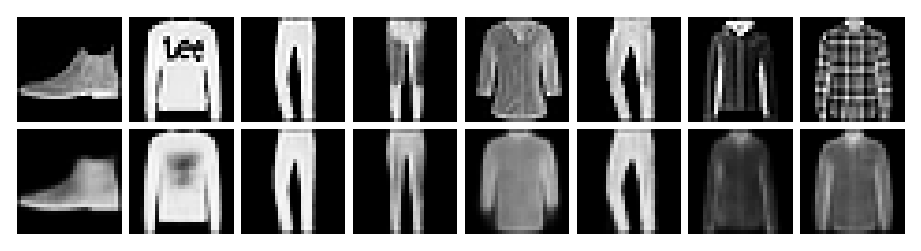

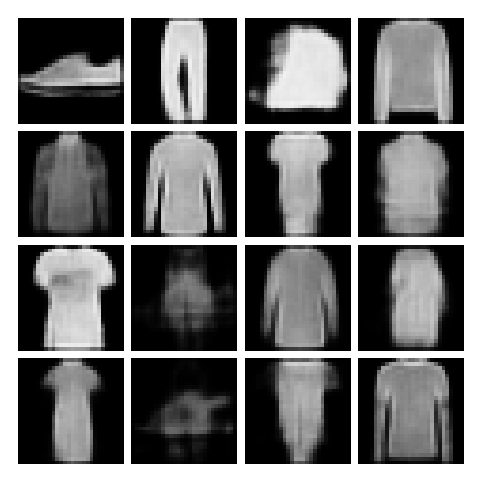

In [7]:
@torch.no_grad()
def show_reconstructions(model, loader, device, n=8):
    model.eval()
    x, _ = next(iter(loader))
    x = x[:n].to(device)
    logits, _, _ = model(x)
    # Sigmoid is only for visualization; training used logits directly.
    recon = torch.sigmoid(logits).view(-1, 1, 28, 28)

    grid = torch.cat([x.cpu(), recon.cpu()], dim=0)
    image = utils.make_grid(grid, nrow=n, pad_value=1.0)
    plt.figure(figsize=(1.5 * n, 3.0))
    plt.imshow(image.permute(1, 2, 0), cmap="gray")
    plt.axis("off")
    plt.show()


@torch.no_grad()
def show_samples(model, device, n=16):
    model.eval()
    z = torch.randn(n, latent_dim, device=device)
    logits = model.decode(z)
    samples = torch.sigmoid(logits).view(-1, 1, 28, 28).cpu()
    image = utils.make_grid(samples, nrow=4, pad_value=1.0)
    plt.figure(figsize=(6, 6))
    plt.imshow(image.permute(1, 2, 0), cmap="gray")
    plt.axis("off")
    plt.show()

show_reconstructions(model, test_loader, device)
show_samples(model, device)

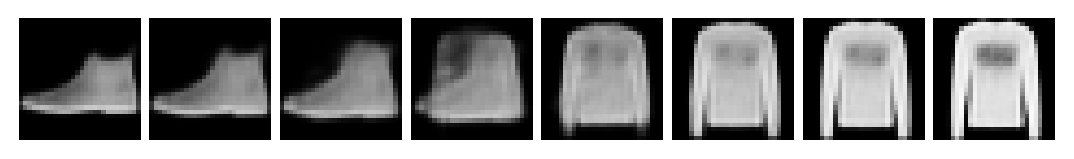

In [8]:
@torch.no_grad()
def interpolate(model, loader, device, steps=8):
    model.eval()
    x, _ = next(iter(loader))
    x0 = x[0:1].to(device)
    x1 = x[1:2].to(device)

    # Interpolate between posterior means to visualize latent geometry.
    mu0, _ = model.encode(x0)
    mu1, _ = model.encode(x1)

    alphas = torch.linspace(0, 1, steps, device=device).view(-1, 1)
    z = (1 - alphas) * mu0 + alphas * mu1
    logits = model.decode(z)
    images = torch.sigmoid(logits).view(-1, 1, 28, 28).cpu()

    grid = utils.make_grid(images, nrow=steps, pad_value=1.0)
    plt.figure(figsize=(1.7 * steps, 2.5))
    plt.imshow(grid.permute(1, 2, 0), cmap="gray")
    plt.axis("off")
    plt.show()


interpolate(model, test_loader, device)

**Interpolation** is particularly revealing when discussing the relation between VAEs and the manifold hypothesis. If linear motion in **latent space** produces gradual semantic motion in image space, that is evidence that the model has learned a coordinate system with some geometric coherence. It does not prove that the **latent space** is the true data manifold, but it does show that the model is organizing variation in a more structured way than raw pixel space does.

## Quantitative Evaluation

Visual inspection is necessary but incomplete. **FID** and **KID** compare real and generated images in a feature space, giving a distribution-level diagnostic. For a VAE, these metrics are especially useful because reconstruction quality can look acceptable even when **prior samples** are weak. The model may know how to decode latent points produced by the encoder while still behaving poorly on latent points sampled directly from the prior.

In [9]:
def prepare_for_inception_metrics(images):
    # The default Inception feature extractor expects RGB-like inputs.
    if images.size(1) == 1:
        images = images.repeat(1, 3, 1, 1)
    return images.clamp(0.0, 1.0)


@torch.no_grad()
def compute_vae_fid_and_kid(model, real_loader, device, num_fake=1000, metric_batch_size=64):
    fid = FrechetInceptionDistance(
        feature=2048,
        normalize=True,
        reset_real_features=False,
    ).set_dtype(torch.float64).to(device)
    kid = KernelInceptionDistance(
        feature=2048,
        subsets=10,
        subset_size=100,
        normalize=True,
        reset_real_features=False,
    ).to(device)

    # First accumulate features from real images in small batches.
    seen_real = 0
    real_target = num_fake
    for real_images, _ in tqdm(real_loader, desc="VAE real metrics", leave=False):
        remaining = real_target - seen_real
        if remaining <= 0:
            break
        real_images = real_images[: min(metric_batch_size, remaining)].to(device)
        real_images = prepare_for_inception_metrics(real_images)
        fid.update(real_images, real=True)
        kid.update(real_images, real=True)
        seen_real += real_images.size(0)

    # Then accumulate features from generated samples.
    generated = 0
    pbar = tqdm(total=num_fake, desc="VAE fake metrics", leave=False)
    while generated < num_fake:
        batch_n = min(metric_batch_size, num_fake - generated)
        z = torch.randn(batch_n, latent_dim, device=device)
        logits = model.decode(z)
        fake_images = torch.sigmoid(logits).view(-1, 1, 28, 28)
        fake_images = prepare_for_inception_metrics(fake_images)
        fid.update(fake_images, real=False)
        kid.update(fake_images, real=False)
        generated += batch_n
        pbar.update(batch_n)
    pbar.close()

    kid_mean, kid_std = kid.compute()
    return {
        "fid": fid.compute().item(),
        "kid_mean": kid_mean.item(),
        "kid_std": kid_std.item(),
    }


metric_scores = compute_vae_fid_and_kid(model, test_loader, device)
print(metric_scores)

c:\Users\tivog\deep-generative-models\.venv\lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: Metric `Kernel Inception Distance` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


VAE real metrics:   0%|          | 0/79 [00:00<?, ?it/s]

VAE fake metrics:   0%|          | 0/1000 [00:00<?, ?it/s]

{'fid': 86.49043233491733, 'kid_mean': 0.06395631283521652, 'kid_std': 0.005002717953175306}


This evaluation block also clarifies one of the VAE's characteristic tradeoffs. A VAE may reconstruct cleanly and organize **latent space** nicely, yet still obtain weaker FID or KID than a sharper generator because the decoded samples can look slightly smooth or blurry in feature space. That does not make the model useless. It means the metric is emphasizing a specific aspect of generative quality, namely closeness of the generated feature distribution to the real one.

## Sampling, Jensen Gap, and the Vanilla VAE Limitations

After training, sampling is simple:

:::{math}
\boldsymbol{z} \sim p(\boldsymbol{z}) = \mathcal{N}(\boldsymbol{0},\boldsymbol{I}),
\qquad
\boldsymbol{x} \sim p_\theta(\boldsymbol{x}|\boldsymbol{z}).
:::

In a neural implementation, the second step usually means passing $\boldsymbol{z}$ through the decoder and either sampling pixels from the output distribution or using the decoder mean/probabilities as the displayed image. This is the payoff of the KL regularization: the decoder has been trained on latent codes that are encouraged to remain compatible with the same prior used at generation time.

The derivation also reveals why vanilla VAEs have characteristic limitations. The first issue is the **Jensen gap**. The ELBO is a lower bound, not the exact likelihood:

:::{math}
\log p_\theta(\boldsymbol{x})
-
\mathcal{L}_{ELBO}(\theta,\phi;\boldsymbol{x})
=
\operatorname{KL}
\left(
q_\phi(\boldsymbol{z}|\boldsymbol{x})
\| p_\theta(\boldsymbol{z}|\boldsymbol{x})
\right).
:::

When the approximate posterior cannot match the **true posterior**, the bound is loose. Optimizing the bound can then differ substantially from optimizing the true likelihood. This is not a small technicality. It means that the model is trained through a surrogate objective whose quality depends on the inference network and variational family.

The second issue is the **balancing problem**. The **reconstruction term** asks the latent code to carry information that helps reproduce the image. The **KL term** asks the approximate posterior to remain close to the simple prior. Both forces are necessary, but they pull in different directions. If reconstruction dominates, the model may behave like a noisy autoencoder whose latent distribution is hard to sample from. If the **KL term** dominates, the **latent channel** may carry too little information.

```{figure} ../assets/images/VAE_mode_collapse.png
:width: 66%
:align: center

**Mode collapse** happens because the $D_{KL}$ term is too strong.
```

The third issue is **posterior collapse**. In this failure mode, the encoder outputs a posterior close to the prior for many inputs, so the decoder receives almost no input-specific information from $\boldsymbol{z}$. A coordinate-wise version is a dead **latent dimension**: one coordinate remains distributed nearly as standard normal noise regardless of the image. The coordinate exists in the architecture, but it transmits essentially no information.

The fourth issue is **aggregate posterior versus prior mismatch**. The ELBO regularizes each per-image posterior $q_\phi(\boldsymbol{z}|\boldsymbol{x})$ toward $p(\boldsymbol{z})$, but generation samples from the prior directly. What matters for sampling is whether the encoded population, averaged over the data distribution, occupies the same regions as the prior. Good reconstructions do not automatically imply good **prior samples**.

The fifth issue is **blurriness**. Pixelwise likelihoods such as Bernoulli or Gaussian decoders reward safe averages when the conditional output is ambiguous. If several sharp images are plausible under a latent code, their average may have good pixelwise likelihood but poor perceptual quality. This is one reason VAE variants explore richer decoders, learned priors, hierarchical latents, perceptual losses, adversarial losses, and modified KL schedules. The survey by Asperti, Evangelista, and Loli Piccolomini {cite}`asperti2021greenvae` organizes many such variants around these limitations and their computational cost.

```{admonition} Main VAE tension
:class: warning

The same **KL term** that makes prior sampling meaningful can also restrict the information carried by $\boldsymbol{z}$. This is the source of the reconstruction-sampling tradeoff, **posterior collapse**, and the need for KL-weight variants.
```

```{prf:theorem} Expected KL as information plus prior mismatch
:label: thm-vae-kl-information-decomposition

Let $p_{gt}(\boldsymbol{x})$ be the data distribution, let $q_\phi(\boldsymbol{z} | \boldsymbol{x})$ be the encoder, and define the **aggregate posterior**
:::{math}
q_\phi(\boldsymbol{z}) = \int q_\phi(\boldsymbol{z} | \boldsymbol{x}) p_{gt}(\boldsymbol{x})\, d\boldsymbol{x}.
:::
Then
:::{math}
\mathbb{E}_{p_{gt}(\boldsymbol{x})}
\operatorname{KL}\big(q_\phi(\boldsymbol{z} | \boldsymbol{x}) \| p(\boldsymbol{z})\big)
=
I_q(\boldsymbol{x};\boldsymbol{z})
+
\operatorname{KL}\big(q_\phi(\boldsymbol{z}) \| p(\boldsymbol{z})\big),
:::
where $I_q(\boldsymbol{x};\boldsymbol{z})$ is the mutual information under the joint distribution $p_{gt}(\boldsymbol{x})q_\phi(\boldsymbol{z} | \boldsymbol{x})$.
```

```{prf:proof}
Start from the expected **KL term** and insert the **aggregate posterior**:
:::{math}
\mathbb{E}_{p_{gt}(\boldsymbol{x})}
\operatorname{KL}\big(q_\phi(\boldsymbol{z} | \boldsymbol{x}) \| p(\boldsymbol{z})\big)
=
\int p_{gt}(\boldsymbol{x})q_\phi(\boldsymbol{z} | \boldsymbol{x})
\log \frac{q_\phi(\boldsymbol{z} | \boldsymbol{x})}{p(\boldsymbol{z})}
\,d\boldsymbol{z}\,d\boldsymbol{x}.
:::
Multiply and divide inside the logarithm by $q_\phi(\boldsymbol{z})$:
:::{math}
\log \frac{q_\phi(\boldsymbol{z} | \boldsymbol{x})}{p(\boldsymbol{z})}
=
\log \frac{q_\phi(\boldsymbol{z} | \boldsymbol{x})}{q_\phi(\boldsymbol{z})}
+
\log \frac{q_\phi(\boldsymbol{z})}{p(\boldsymbol{z})}.
:::
The first integral is exactly the mutual information between $\boldsymbol{x}$ and $\boldsymbol{z}$ under the encoder joint. In the second integral, integration over $\boldsymbol{x}$ turns $p_{gt}(\boldsymbol{x})q_\phi(\boldsymbol{z} | \boldsymbol{x})$ into $q_\phi(\boldsymbol{z})$, giving the KL divergence between the **aggregate posterior** and the prior.
```

This theorem is a useful diagnostic lens. The average **KL term** is not a single monolithic penalty. It simultaneously controls how much information the latent variable carries about the input and how closely the encoded population matches the prior used at sampling time. Posterior collapse corresponds to the information term becoming too small. Poor **prior samples** can arise when the aggregate-posterior mismatch remains large even though reconstructions look acceptable. Many VAE variants can be read as attempts to control one side of this decomposition more precisely.

The broader lesson is that a VAE is best understood as a coupled system: probabilistic assumptions, latent geometry, decoder likelihood, inference approximation, and optimization all interact. Changing the KL weight, **latent dimension**, **decoder capacity**, or observation model changes the balance between reconstruction, sample quality, and latent usage.

The VAE is the canonical bridge between probabilistic latent-variable modeling and neural network autoencoding. It begins as a maximum-likelihood problem, becomes difficult because marginalization and posterior inference are intractable, introduces a variational posterior to obtain the ELBO, and finally takes the shape of a **stochastic autoencoder** trained by reparameterized gradients. Its limitations are not failures of the derivation. They are the visible consequences of the approximations that make the model trainable.